# EDA — Estadísticas Descriptivas y Distribuciones
## Dataset SnapUGC v2 — ICCV VQualA Challenge 2025

Este notebook cubre el análisis exploratorio de las distribuciones del ECR y la duración
en el dataset SnapUGC v2, tanto a nivel del conjunto de entrenamiento como en comparación
entre las tres particiones oficiales (train / val / test).

**Aporte original OE1**: Identificación y caracterización de sesgos sistemáticos en la
distribución del ECR entre los subconjuntos del challenge, no documentados en los trabajos
de referencia.

Dataset: 106,192 (train) + 6,000 (val) + 8,459 (test) = 120,651 vídeos totales.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy import stats
from scipy.stats import gaussian_kde
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family': 'serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.facecolor': '#F9F9F9',
    'figure.facecolor': 'white',
})

BASE_RAW  = '../data/raw/'
BASE_PROC = '../data/processed/'
BLUE   = '#2E6FA3'
CORAL  = '#D95F4B'
GREEN  = '#4A9B7F'

In [2]:
# ── TRAIN
train_data = pd.read_csv(BASE_RAW + 'train_data.csv')
train_meta = pd.read_csv(BASE_PROC + 'train_metadata.csv')
df_train   = train_data.merge(train_meta, on='Id', how='inner')
df_train['has_title']       = df_train['Title'].notna() & (df_train['Title'].str.strip() != '')
df_train['has_description'] = df_train['Description'].notna() & (df_train['Description'].str.strip() != '')
df_train['split'] = 'train'

# Subconjuntos por duración (train)
df_10s_to_60s = df_train[(df_train['duration'] >= 10) & (df_train['duration'] <= 60)]

# ── VALIDATION
val_data = pd.read_csv(BASE_RAW + 'val_data.csv')
val_meta = pd.read_csv(BASE_PROC + 'val_metadata.csv')
df_val   = val_data.merge(val_meta, on='Id', how='inner')
df_val['has_title']       = df_val['Title'].notna() & (df_val['Title'].str.strip() != '')
df_val['has_description'] = df_val['Description'].notna() & (df_val['Description'].str.strip() != '')
df_val['split'] = 'val'

# ── TEST
test_data = pd.read_csv(BASE_RAW + 'test_data.csv')
test_meta = pd.read_csv(BASE_PROC + 'test_metadata.csv')
df_test   = test_data.merge(test_meta, on='Id', how='inner')
df_test['has_title']       = df_test['Title'].notna() & (df_test['Title'].str.strip() != '')
df_test['has_description'] = df_test['Description'].notna() & (df_test['Description'].str.strip() != '')
df_test['split'] = 'test'

print(f'Train: {len(df_train):,} | Val: {len(df_val):,} | Test: {len(df_test):,}')
print(f'Total: {len(df_train)+len(df_val)+len(df_test):,}')
print(f'\nTrain — vídeos <10s:   {(df_train["duration"] < 10).sum():,} ({(df_train["duration"] < 10).mean()*100:.1f}%)')
print(f'Train — vídeos 10-60s: {len(df_10s_to_60s):,} ({len(df_10s_to_60s)/len(df_train)*100:.1f}%)')
print(f'Train — vídeos >60s:   {(df_train["duration"] > 60).sum():,}')

Train: 106,192 | Val: 6,000 | Test: 8,459
Total: 120,651

Train — vídeos <10s:   55,423 (52.2%)
Train — vídeos 10-60s: 49,855 (46.9%)
Train — vídeos >60s:   816


## 1. Estadísticas descriptivas por partición

In [3]:
pcts = [5, 25, 50, 75, 95]
rows = []
for name, df in [('train', df_train), ('val', df_val), ('test', df_test)]:
    ecr = df['ECR'].dropna()
    dur = df['duration'].dropna()
    row = {
        'Split': name,
        'N': f'{len(df):,}',
        'ECR mean': f'{ecr.mean():.3f}',
        'ECR std':  f'{ecr.std():.3f}',
        **{f'ECR P{p}': f'{np.percentile(ecr, p):.3f}' for p in pcts},
        'Dur mean (s)': f'{dur.mean():.1f}',
        'Dur median (s)': f'{np.median(dur):.1f}',
        'Dur std (s)': f'{dur.std():.1f}',
        **{f'Dur P{p}': f'{np.percentile(dur, p):.1f}' for p in pcts},
        'has_title (%)': f'{df["has_title"].mean()*100:.1f}',
        'has_desc (%)':  f'{df["has_description"].mean()*100:.1f}',
        '% < 10s': f'{(df["duration"] < 10).mean()*100:.1f}',
    }
    rows.append(row)

stats_df = pd.DataFrame(rows).set_index('Split')
print(stats_df.T.to_string())

Split             train    val   test
N               106,192  6,000  8,459
ECR mean          0.498  0.493  0.502
ECR std           0.290  0.290  0.291
ECR P5            0.046  0.045  0.045
ECR P25           0.246  0.244  0.248
ECR P50           0.497  0.485  0.508
ECR P75           0.748  0.746  0.756
ECR P95           0.951  0.949  0.947
Dur mean (s)       15.6   15.4   15.5
Dur median (s)      9.7    9.6    9.7
Dur std (s)        14.0   13.8   13.8
Dur P5              5.3    5.3    5.3
Dur P25             6.8    6.8    6.8
Dur P50             9.7    9.6    9.7
Dur P75            17.9   17.6   17.6
Dur P95            54.0   51.4   52.6
has_title (%)      37.4   37.6   37.7
has_desc (%)       42.6   44.0   43.1
% < 10s            52.2   53.0   52.4


### Interpretación: Estadísticas descriptivas

Las tres particiones son estadísticamente muy similares en todas las variables analizadas.
El ECR presenta una distribución casi uniforme en [0, 1] con media ~0.498 y desviación
típica ~0.290 en las tres particiones. La duración tiene una distribución log-normal
con mediana ~9.7 s, reflejo del formato dominante de vídeo muy corto en la plataforma.

Destaca que aproximadamente el **52% de los vídeos en cada partición tiene duración
inferior a 10 segundos** — una propiedad estructural del dataset v2, no un artefacto
del muestreo (véase Sección 3).

## 2. Distribución del ECR — Conjunto de entrenamiento

### 2.1 Dataset completo (5–60 s)

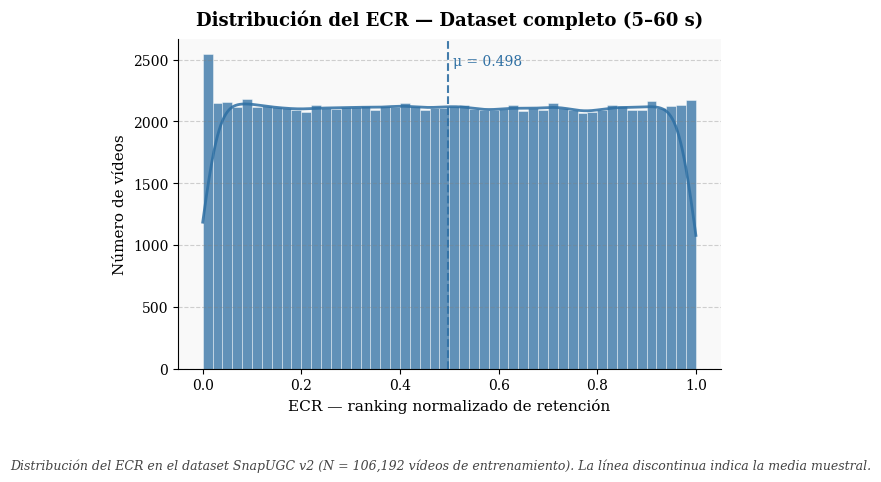

In [4]:
fig, ax = plt.subplots(figsize=(7, 5))
fig.subplots_adjust(bottom=0.22)

ecr_data = df_train['ECR'].dropna()
counts, bins, _ = ax.hist(ecr_data, bins=50, edgecolor='white', linewidth=0.4, alpha=0.75, color=BLUE)

kde = gaussian_kde(ecr_data, bw_method=0.10)
xs = np.linspace(ecr_data.min(), ecr_data.max(), 1200)
bin_width = bins[1] - bins[0]
kde_scaled = kde(xs) * len(ecr_data) * bin_width
ax.plot(xs, kde_scaled, color=BLUE, lw=2, alpha=0.85)

mean_ecr = ecr_data.mean()
ax.axvline(mean_ecr, color=BLUE, lw=1.5, ls='--', alpha=0.9)
ax.text(mean_ecr + 0.01, ax.get_ylim()[1] * 0.92, f'μ = {mean_ecr:.3f}', color=BLUE, fontsize=10)

ax.set_xlabel('ECR — ranking normalizado de retención', fontsize=11)
ax.set_ylabel('Número de vídeos', fontsize=11)
ax.set_title('Distribución del ECR — Dataset completo (5–60 s)', fontsize=13, fontweight='bold', pad=10)
ax.grid(axis='y', linestyle='--', alpha=0.35, color='grey')

fig.text(0.5, 0.04,
    f'Distribución del ECR en el dataset SnapUGC v2 (N = {len(df_train):,} vídeos de entrenamiento). '
    'La línea discontinua indica la media muestral.',
    ha='center', va='top', fontsize=9, color='#444444', style='italic')

plt.savefig('../results/ecr_dist.png', dpi=300, bbox_inches='tight')
plt.show()

### 2.2 Filtrado: vídeos ≥ 10 s

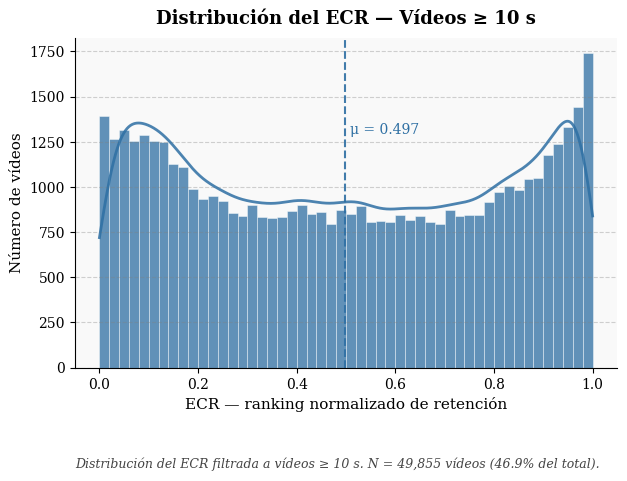

In [5]:
fig, ax = plt.subplots(figsize=(7, 5))
fig.subplots_adjust(bottom=0.22)

ecr_10s = df_10s_to_60s['ECR'].dropna()
counts, edges, _ = ax.hist(ecr_10s, bins=50, edgecolor='white', linewidth=0.4, alpha=0.75, color=BLUE)

kde = gaussian_kde(ecr_10s, bw_method=0.10)
xs = np.linspace(ecr_10s.min(), ecr_10s.max(), 1200)
kde_scaled = kde(xs) / kde(xs).max() * np.percentile(counts, 95)
ax.plot(xs, kde_scaled, color=BLUE, lw=2, alpha=0.85)

mean_ecr = ecr_10s.mean()
ax.axvline(mean_ecr, color=BLUE, lw=1.5, ls='--', alpha=0.9)
ax.text(mean_ecr + 0.01, np.percentile(counts, 95) * 0.95,
        f'μ = {mean_ecr:.3f}', color=BLUE, fontsize=10)

ax.set_xlabel('ECR — ranking normalizado de retención', fontsize=11)
ax.set_ylabel('Número de vídeos', fontsize=11)
ax.set_title('Distribución del ECR — Vídeos ≥ 10 s', fontsize=13, fontweight='bold', pad=10)
ax.grid(axis='y', linestyle='--', alpha=0.35, color='grey')

fig.text(0.5, 0.04,
    f'Distribución del ECR filtrada a vídeos ≥ 10 s. '
    f'N = {len(df_10s_to_60s):,} vídeos ({len(df_10s_to_60s)/len(df_train)*100:.1f}% del total).',
    ha='center', va='top', fontsize=9, color='#444444', style='italic')

plt.savefig('../results/ecr_dist_10sto60s.png', dpi=300, bbox_inches='tight')
plt.show()

### Análisis: distribución uniforme vs. bimodal

Cuando se analiza el conjunto completo del challenge (N = 106.192 vídeos, 5–60 s),
la distribución del ECR presenta una forma **aproximadamente uniforme** en [0, 1]
(figura anterior). Este comportamiento contrasta con la distribución bimodal documentada
por Li et al. sobre la primera versión del dataset SnapUGC (v1), que excluía
explícitamente los vídeos de duración inferior a 10 s.

La causa reside en una limitación semántica del ECR para vídeos muy cortos.
El ECR mide si el usuario supera un umbral de visionado de 5 segundos, una
**decisión consciente** de continuar viendo. Sin embargo, en vídeos de duración
igual o próxima a ese umbral, la reproducción automática de la plataforma hace
que el umbral se supere —o no— antes de que el usuario haya podido evaluar el
contenido y actuar en consecuencia. El ECR de estos vídeos refleja la
**velocidad de reacción del usuario**, no su interés real por el contenido,
generando valores distribuidos casi aleatoriamente en [0, 1].

Al filtrar a `duration ≥ 10s` (N = 49.855 vídeos), la distribución recupera
el **patrón bimodal** característico: un primer pico en torno a ECR ≈ 0.1
(usuarios que descartan el vídeo) y un segundo pico próximo a ECR ≈ 0.9
(vídeos que retienen la atención). Esta polarización refleja la dinámica
de consumo basada en *swipe* de las plataformas de vídeo corto.

> **Nota metodológica:** el filtro `duration ≥ 10s` se aplica aquí únicamente
> con fines exploratorios. Los experimentos de modelado se realizan sobre el
> conjunto completo, respetando las condiciones oficiales del challenge.

## 3. Comparativa bimodal: vídeos < 10 s vs. ≥ 10 s

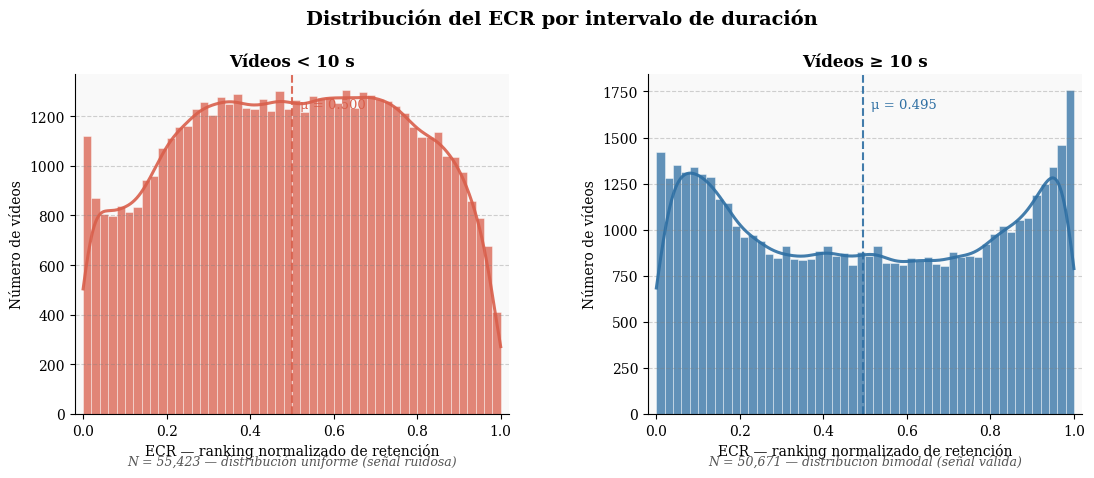

In [6]:
ecr_short = df_train[df_train['duration'] < 10]['ECR'].dropna()
ecr_long  = df_train[df_train['duration'] >= 10]['ECR'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)
fig.subplots_adjust(bottom=0.20, wspace=0.32)

for ax, data, color, title, subtitle in [
    (axes[0], ecr_short, CORAL,
     'Vídeos < 10 s',
     f'N = {len(ecr_short):,} — distribución uniforme (señal ruidosa)'),
    (axes[1], ecr_long, BLUE,
     'Vídeos ≥ 10 s',
     f'N = {len(ecr_long):,} — distribución bimodal (señal válida)'),
]:
    counts, bins, _ = ax.hist(data, bins=50, edgecolor='white', linewidth=0.4, alpha=0.75, color=color)
    kde = gaussian_kde(data, bw_method=0.10)
    xs = np.linspace(0, 1, 600)
    bin_width = bins[1] - bins[0]
    kde_scaled = kde(xs) * len(data) * bin_width
    ax.plot(xs, kde_scaled, color=color, lw=2.2, alpha=0.9)
    ax.axvline(data.mean(), color=color, lw=1.5, ls='--', alpha=0.9)
    ax.text(data.mean() + 0.02, ax.get_ylim()[1] * 0.90,
            f'μ = {data.mean():.3f}', color=color, fontsize=9.5)
    ax.set_xlabel('ECR — ranking normalizado de retención', fontsize=10)
    ax.set_ylabel('Número de vídeos', fontsize=10)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlim(-0.02, 1.02)
    ax.grid(axis='y', linestyle='--', alpha=0.35, color='grey')
    ax.text(0.5, -0.15, subtitle, ha='center', transform=ax.transAxes,
            fontsize=9, color='#555555', style='italic')

fig.suptitle('Distribución del ECR por intervalo de duración',
             fontsize=14, fontweight='bold', y=1.01)
plt.savefig('../results/ecr_bimodal_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [7]:
print('=' * 62)
print('VÍDEOS CON DURACIÓN < 10 s POR PARTICIÓN')
print('=' * 62)
for name, df in [('train', df_train), ('val', df_val), ('test', df_test)]:
    n_short = (df['duration'] < 10).sum()
    pct     = n_short / len(df) * 100
    print(f'{name:6s}: {n_short:6,} vídeos < 10s  ({pct:.1f}% del total)')

print()
print(f'ECR medio vídeos <10s  (train): {ecr_short.mean():.3f} ± {ecr_short.std():.3f}')
print(f'ECR medio vídeos ≥10s (train): {ecr_long.mean():.3f} ± {ecr_long.std():.3f}')
ks_s, p_s = stats.ks_2samp(ecr_short, ecr_long)
print(f'KS test <10s vs ≥10s:  stat={ks_s:.4f},  p={p_s:.2e}')

VÍDEOS CON DURACIÓN < 10 s POR PARTICIÓN
train : 55,423 vídeos < 10s  (52.2% del total)
val   :  3,179 vídeos < 10s  (53.0% del total)
test  :  4,430 vídeos < 10s  (52.4% del total)

ECR medio vídeos <10s  (train): 0.500 ± 0.267
ECR medio vídeos ≥10s (train): 0.495 ± 0.314
KS test <10s vs ≥10s:  stat=0.0862,  p=9.18e-172


### Interpretación: ECR como señal ruidosa para vídeos < 10 s

El test KS entre vídeos <10 s y ≥10 s arroja un estadístico de 0.086 con p=9.18×10⁻¹⁷² —
evidencia estadística abrumadora de que las distribuciones de ECR son cualitativamente
distintas. Los vídeos cortos (<10 s) presentan una distribución de ECR casi uniforme
(media ~0.500), sin la estructura bimodal característica de los vídeos más largos
(media ~0.495 con mayor dispersión en los extremos).

La proporción de vídeos cortos (~52%) es **constante entre las tres particiones**,
lo que confirma que es una propiedad estructural del dataset v2 y no un artefacto
del muestreo. Esta observación es coherente con la decisión de Li et al. (ECCV 2024)
de excluir los vídeos <10 s en la versión original del benchmark.

## 4. Distribución de la duración

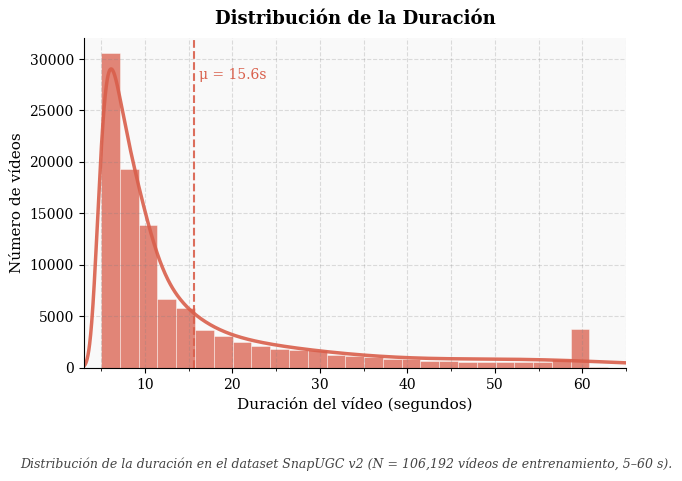

In [8]:
fig, ax = plt.subplots(figsize=(7, 5))
fig.subplots_adjust(bottom=0.22)

data_dur = df_train['duration'].dropna().values
counts, edges, _ = ax.hist(data_dur, bins=50, edgecolor='white',
                            linewidth=0.4, alpha=0.75, color=CORAL)

# KDE en escala log (corrección jacobiana para distribución log-normal)
log_data = np.log(data_dur)
kde = gaussian_kde(log_data, bw_method=0.25)
xs_log  = np.linspace(np.log(3), np.log(65), 600)
xs_orig = np.exp(xs_log)
kde_vals_corrected = kde(xs_log) / xs_orig
kde_scaled = kde_vals_corrected / kde_vals_corrected.max() * counts.max() * 0.95
ax.plot(xs_orig, kde_scaled, color=CORAL, lw=2.5, alpha=0.9)

mean_dur = data_dur.mean()
ax.axvline(mean_dur, color=CORAL, lw=1.5, ls='--', alpha=0.9)
ax.text(mean_dur + 0.5, counts.max() * 0.92,
        f'μ = {mean_dur:.1f}s', color=CORAL, fontsize=10)

ax.set_xlabel('Duración del vídeo (segundos)', fontsize=11)
ax.set_xlim(3, 65)
ax.set_ylabel('Número de vídeos', fontsize=11)
ax.set_title('Distribución de la Duración', fontsize=13, fontweight='bold', pad=10)
ax.xaxis.set_major_locator(ticker.MultipleLocator(10))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(5))
ax.grid(axis='both', which='both', linestyle='--', alpha=0.25, color='grey')

fig.text(0.5, 0.04,
    f'Distribución de la duración en el dataset SnapUGC v2 '
    f'(N = {len(df_train):,} vídeos de entrenamiento, 5–60 s).',
    ha='center', va='top', fontsize=9, color='#444444', style='italic')

plt.savefig('../results/duration_dist.png', dpi=300, bbox_inches='tight')
plt.show()

### Interpretación: Distribución de la duración

La duración presenta una distribución claramente log-normal con un pico pronunciado
en torno a los 7–10 segundos, reflejo del formato dominante de vídeo muy corto en la
plataforma Snapchat Spotlight. La media (15.6 s) supera considerablemente a la mediana
(9.7 s), evidenciando la cola derecha generada por los vídeos de mayor duración.

Prácticamente todos los vídeos tienen duración entre 5 s y 60 s (solo 21 vídeos superan
los 60 s, un 0.02% del total), lo que confirma que los límites declarados del dataset
son efectivos.

## 5. Análisis comparativo por partición (Train / Val / Test)

### 5.1 Distribución del ECR por partición (KDE overlay)

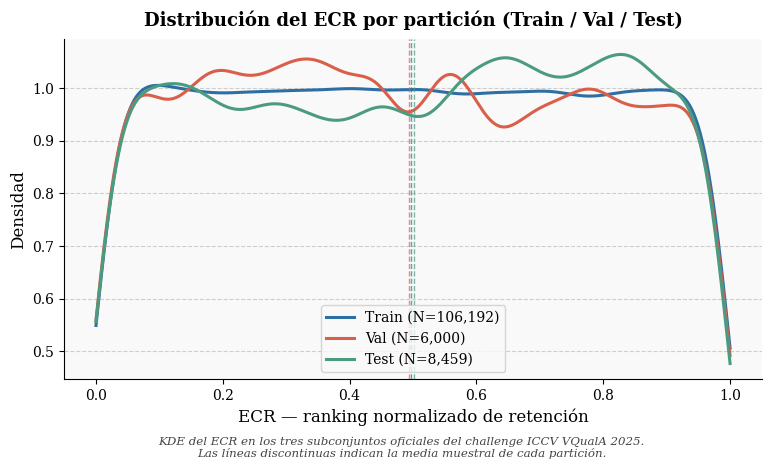

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
fig.subplots_adjust(bottom=0.20)

split_ecr = [
    (df_train['ECR'].dropna(), BLUE,  'Train (N=106,192)'),
    (df_val['ECR'].dropna(),   CORAL, 'Val (N=6,000)'),
    (df_test['ECR'].dropna(),  GREEN, 'Test (N=8,459)'),
]

for data, color, label in split_ecr:
    kde = gaussian_kde(data, bw_method=0.12)
    xs  = np.linspace(0, 1, 600)
    ax.plot(xs, kde(xs), color=color, lw=2.2, label=label)
    ax.axvline(data.mean(), color=color, lw=1.0, ls='--', alpha=0.7)

ax.set_xlabel('ECR — ranking normalizado de retención', fontsize=12)
ax.set_ylabel('Densidad', fontsize=12)
ax.set_title('Distribución del ECR por partición (Train / Val / Test)',
             fontsize=13, fontweight='bold', pad=10)
ax.legend(fontsize=10, framealpha=0.8)
ax.grid(axis='y', linestyle='--', alpha=0.35, color='grey')

fig.text(0.5, 0.04,
    'KDE del ECR en los tres subconjuntos oficiales del challenge ICCV VQualA 2025.\n'
    'Las líneas discontinuas indican la media muestral de cada partición.',
    ha='center', va='bottom', fontsize=8.5, color='#444444', style='italic')

plt.savefig('../results/ecr_kde_splits.png', dpi=300, bbox_inches='tight')
plt.show()

### Interpretación: Distribución del ECR por partición

Las tres particiones presentan distribuciones de ECR muy similares: media en torno a
0.49–0.50, desviación típica ~0.29. Los tests KS confirman que train↔val es
estadísticamente homogéneo (p=0.172), mientras que train↔test y val↔test muestran
diferencias significativas pero de tamaño de efecto muy pequeño (KS stat ≤ 0.027).
Este leve sesgo del conjunto de test —media ECR 0.502 frente a 0.498 en entrenamiento—
es una propiedad del dataset y debe tenerse en cuenta al interpretar los resultados.

### 5.2 Distribución de la duración por partición (KDE overlay)

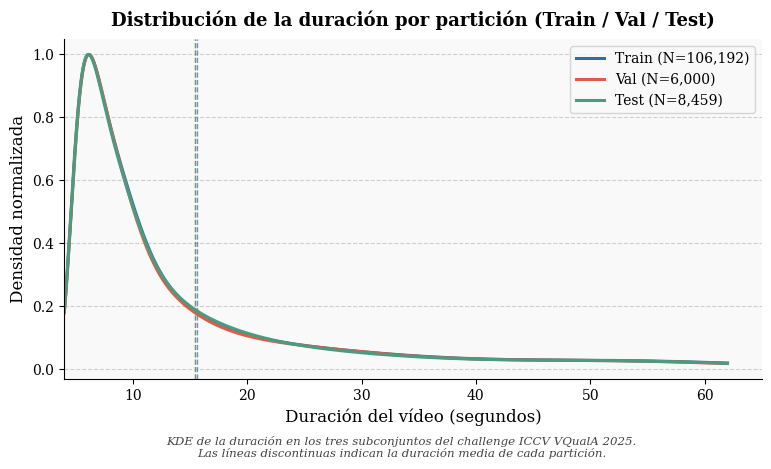

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
fig.subplots_adjust(bottom=0.20)

split_dur = [
    (df_train['duration'].dropna(), BLUE,  'Train (N=106,192)'),
    (df_val['duration'].dropna(),   CORAL, 'Val (N=6,000)'),
    (df_test['duration'].dropna(),  GREEN, 'Test (N=8,459)'),
]

for data, color, label in split_dur:
    log_data = np.log(data.clip(lower=1))
    kde = gaussian_kde(log_data, bw_method=0.25)
    xs_log  = np.linspace(np.log(4), np.log(62), 600)
    xs_orig = np.exp(xs_log)
    kde_vals = kde(xs_log) / xs_orig
    kde_vals = kde_vals / kde_vals.max()
    ax.plot(xs_orig, kde_vals, color=color, lw=2.2, label=label)
    ax.axvline(data.mean(), color=color, lw=1.0, ls='--', alpha=0.7)

ax.set_xlabel('Duración del vídeo (segundos)', fontsize=12)
ax.set_ylabel('Densidad normalizada', fontsize=12)
ax.set_title('Distribución de la duración por partición (Train / Val / Test)',
             fontsize=13, fontweight='bold', pad=10)
ax.set_xlim(4, 65)
ax.legend(fontsize=10, framealpha=0.8)
ax.grid(axis='y', linestyle='--', alpha=0.35, color='grey')

fig.text(0.5, 0.04,
    'KDE de la duración en los tres subconjuntos del challenge ICCV VQualA 2025.\n'
    'Las líneas discontinuas indican la duración media de cada partición.',
    ha='center', va='bottom', fontsize=8.5, color='#444444', style='italic')

plt.savefig('../results/duration_kde_splits.png', dpi=300, bbox_inches='tight')
plt.show()

### Interpretación: Distribución de la duración por partición

La duración es completamente homogénea entre las tres particiones (todos los tests KS
con p > 0.40). La distribución presenta una forma log-normal con un pico pronunciado
en torno a los 7–10 segundos. El ~52% de vídeos cortos (<10 s) es constante en las
tres particiones, confirmando que es una característica estructural del dataset v2.

## 6. Tests de Kolmogorov-Smirnov — Comparabilidad entre particiones

**H₀**: las dos distribuciones provienen de la misma distribución de probabilidad.  
**p < 0.05** → sesgo distribucional detectado → las particiones no son intercambiables.

In [11]:
pairs = [
    ('ECR',      df_train['ECR'].dropna(),      df_val['ECR'].dropna(),       'train vs val'),
    ('ECR',      df_train['ECR'].dropna(),      df_test['ECR'].dropna(),      'train vs test'),
    ('ECR',      df_val['ECR'].dropna(),        df_test['ECR'].dropna(),      'val vs test'),
    ('duration', df_train['duration'].dropna(), df_val['duration'].dropna(),  'train vs val'),
    ('duration', df_train['duration'].dropna(), df_test['duration'].dropna(), 'train vs test'),
    ('duration', df_val['duration'].dropna(),   df_test['duration'].dropna(), 'val vs test'),
]

print(f'{"Variable":10s} | {"Comparación":18s} | {"KS stat":8s} | {"p-valor":10s} | Veredicto')
print('-' * 70)
for var, a, b, pair in pairs:
    ks_stat, p_val = stats.ks_2samp(a, b)
    verdict = 'SESGO DETECTADO ⚠' if p_val < 0.05 else 'OK (sin sesgo) ✓'
    print(f'{var:10s} | {pair:18s} | {ks_stat:8.4f} | {p_val:10.2e} | {verdict}')

print()
print('Nota: p < 0.05 indica distribuciones estadísticamente distintas.')

Variable   | Comparación        | KS stat  | p-valor    | Veredicto
----------------------------------------------------------------------
ECR        | train vs val       |   0.0147 |   1.72e-01 | OK (sin sesgo) ✓
ECR        | train vs test      |   0.0165 |   2.84e-02 | SESGO DETECTADO ⚠
ECR        | val vs test        |   0.0269 |   1.23e-02 | SESGO DETECTADO ⚠
duration   | train vs val       |   0.0129 |   3.03e-01 | OK (sin sesgo) ✓
duration   | train vs test      |   0.0097 |   4.55e-01 | OK (sin sesgo) ✓
duration   | val vs test        |   0.0146 |   4.42e-01 | OK (sin sesgo) ✓

Nota: p < 0.05 indica distribuciones estadísticamente distintas.


### Interpretación: Tests de Kolmogorov-Smirnov

Los resultados revelan un patrón asimétrico: **la partición de validación es
estadísticamente comparable a la de entrenamiento** (ECR: p=0.172; duración: p=0.303),
mientras que el conjunto de test muestra una desviación leve pero significativa en ECR
(train↔test: KS=0.0165, p=0.028; val↔test: KS=0.0269, p=0.012).

Sin embargo, el tamaño del efecto es mínimo: un estadístico KS de 0.027 indica que las
distribuciones acumuladas difieren como máximo en un 2.7% en cualquier punto. La
**duración** es homogénea en todos los pares (p > 0.30), confirmando que el sesgo en
ECR no se explica por composiciones diferentes de tipos de vídeo.

## Conclusiones del análisis

| Análisis | Resultado |
|----------|-----------|
| ECR train↔val | ✓ Homogéneo (p=0.172) |
| ECR train↔test | ⚠ Sesgo leve (p=0.028, KS=0.017) |
| ECR val↔test | ⚠ Sesgo leve (p=0.012, KS=0.027) |
| Duración (todos los pares) | ✓ Homogéneo (p > 0.30) |
| Vídeos < 10 s | ~52% en cada partición |
| ECR < 10 s vs ≥ 10 s | ⚠ Distribuciones distintas (p ≈ 9×10⁻¹⁷²) |

**Implicación para el diseño experimental:** Las métricas de evaluación se reportan
sobre la partición de validación oficial (val), que es estadísticamente comparable
a entrenamiento. El ligero sesgo del conjunto de test es una limitación menor del
dataset y no invalida la comparación de modelos entre sí.